# 입력 feature 선택 및 RandomForest 모델 학습 및 검증

이전 EDA / Isolation Forest 실험 (`isolation_27_h1(v1)_v4.ipynb`) 에서 전체적으로 allow / block 분리 신호는 있었지만, CAPTCHA 구간 anomaly recall 이 약 0.245 로 낮았다. 본 노트북에서는 label 이 있는 allow / block 데이터를 사용해 **RandomForest supervised baseline** 을 만들고, 특히 CAPTCHA recall 이 IF 대비 개선되는지를 확인한다. 또한 type 별 `predict_proba` 분포가 얼마나 분리되는지 살펴 pooled 모델에서 type 별 threshold 조정 근거가 있는지 검토한다.


## 1. 데이터 준비


### 1.1 ⚙️ 학습 설정 (args)


In [1]:
import os
import json
import time
import warnings
from pathlib import Path
from types import SimpleNamespace

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, RocCurveDisplay, PrecisionRecallDisplay,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)
sns.set_style("whitegrid")

args = SimpleNamespace(
    RUN_VERSION="randomforest_28_allow_block_type_v1",
    DATA_ROOT="../../data/data_0514_1800_v2",
    MODEL_SAVE_DIR="../model_joblib/randomforest_28_allow_block_type_v1",
    RANDOM_STATE=42,
    TEST_SIZE=0.2,
    MAX_MISSING_RATE=0.3,
    USE_TYPE_AS_FEATURE=False,
    SAVE_MODEL=True,
)
args


ModuleNotFoundError: No module named 'seaborn'

### 1.2 데이터 로드 헬퍼 함수


In [2]:
TYPE_MAP = {"booking": "BOOKING", "captcha": "CAPTCHA", "detail": "DETAIL"}
LABEL_MAP = {"allow": "ALLOW", "block": "BLOCK"}


def _match_from_parts(parts_lower, mapping):
    hits = [v for k, v in mapping.items() if k in parts_lower]
    return hits


def load_data(root_dir):
    root = Path(root_dir)
    if not root.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {root.resolve()}")
    rows = []
    n_total, n_skip = 0, 0
    for jp in sorted(root.rglob("*.json")):
        n_total += 1
        try:
            with open(jp, encoding="utf-8") as f:
                obj = json.load(f)
        except Exception as e:
            warnings.warn(f"skip {jp}: {e}")
            n_skip += 1
            continue
        flat = pd.json_normalize(obj, sep=".")
        # metrics.* nested dict 의 부모 키 prefix 제거 → feature_names 가 'reclick_rate' 형태로 깔끔하게
        flat.columns = [c.split(".", 1)[1] if c.startswith("metrics.") else c for c in flat.columns]
        parts_lower = [p.lower() for p in jp.parts]
        type_hits = _match_from_parts(parts_lower, TYPE_MAP)
        label_hits = _match_from_parts(parts_lower, LABEL_MAP)
        if len(type_hits) != 1:
            raise ValueError(f"{jp}: type matches {type_hits}")
        if len(label_hits) != 1:
            raise ValueError(f"{jp}: label matches {label_hits}")
        flat["type"] = type_hits[0]
        flat["label_norm"] = label_hits[0]
        flat["y"] = 0 if label_hits[0] == "ALLOW" else 1
        flat["source_path"] = str(jp)
        flat["source_file"] = jp.name
        rows.append(flat)
    df = pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()
    # null-mixed int 컬럼이 object dtype 으로 강등되는 걸 방지: numeric 강제 변환
    _NON_NUMERIC_META = {"type", "label_norm", "source_path", "source_file", "label"}
    for _c in df.columns:
        if _c in _NON_NUMERIC_META or _c == "y":
            continue
        if df[_c].dtype == object:
            df[_c] = pd.to_numeric(df[_c], errors="coerce")
    return df, n_total, n_skip


### 1.3 데이터 로드 실행 ✅


In [3]:
df_eda, n_total, n_skip = load_data(args.DATA_ROOT)
print(f"json files scanned: {n_total}, skipped: {n_skip}, loaded rows: {len(df_eda)}")
print(f"df_eda.shape: {df_eda.shape}")
print("columns (first 50):", df_eda.columns.tolist()[:50])


NameError: name 'args' is not defined

In [4]:
print("\n[label_norm x type crosstab]")
print(pd.crosstab(df_eda["label_norm"], df_eda["type"], margins=True))

print("\n[y distribution]")
print(df_eda["y"].value_counts().sort_index())

print("\n[per-type allow/block counts]")
print(df_eda.groupby(["type", "label_norm"]).size().unstack(fill_value=0))



[label_norm x type crosstab]


NameError: name 'df_eda' is not defined

## 2. 데이터 전처리


### 2.1 feature 후보 선정

- 숫자형 컬럼만 후보로 사용
- y / label / 경로 / id 계열, timestamp / created_at / updated_at substring 컬럼은 제외
- `USE_TYPE_AS_FEATURE = False` → type 은 평가용 group 으로만 사용


In [5]:
EXCLUDE_EXACT = {
    "y", "label_norm", "type", "source_path", "source_file",
    "id", "trial_id", "trialId", "user_id", "session_id",
}
EXCLUDE_SUBSTR = ("timestamp", "created_at", "updated_at")


def is_excluded(col):
    if col in EXCLUDE_EXACT:
        return True
    c = col.lower()
    return any(s in c for s in EXCLUDE_SUBSTR)


numeric_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
feature_candidates = [c for c in numeric_cols if not is_excluded(c)]

if args.USE_TYPE_AS_FEATURE:
    # 현재 default False — 사용 시에는 one-hot 별도로 추가하는 식으로 확장
    pass

print(f"numeric columns: {len(numeric_cols)}")
print(f"feature_candidates: {len(feature_candidates)}")
feature_candidates


NameError: name 'df_eda' is not defined

### 2.2 ✅ 결측치 점검


In [6]:
missing_rate = df_eda[feature_candidates].isna().mean().sort_values(ascending=False)
print("[missing rate per feature]")
print(missing_rate.to_string())

excluded_features = [c for c in feature_candidates if missing_rate[c] > args.MAX_MISSING_RATE]
selected_features = [c for c in feature_candidates if c not in excluded_features]

print(f"\nMAX_MISSING_RATE = {args.MAX_MISSING_RATE}")
print(f"excluded_features ({len(excluded_features)}): {excluded_features}")
print(f"selected_features ({len(selected_features)}):")
for c in selected_features:
    print(f"  - {c}")


NameError: name 'df_eda' is not defined

### 2.3 train / test split


In [7]:
X = df_eda[selected_features].copy()
y = df_eda["y"].copy()
groups_type = df_eda["type"].copy()

X_train, X_test, y_train, y_test, type_train, type_test = train_test_split(
    X, y, groups_type,
    test_size=args.TEST_SIZE,
    random_state=args.RANDOM_STATE,
    stratify=y,
)

print(f"X_train.shape: {X_train.shape}, X_test.shape: {X_test.shape}")
print("\n[train label distribution]")
print(y_train.value_counts().sort_index())
print("\n[test label distribution]")
print(y_test.value_counts().sort_index())
print("\n[train type distribution]")
print(type_train.value_counts())
print("\n[test type distribution]")
print(type_test.value_counts())


NameError: name 'df_eda' is not defined

### 2.4 전처리 파이프라인

- SimpleImputer (median) 만 적용
- RandomForest 는 scaling 불필요 → StandardScaler 없음
- 모델 정의는 §3 에서 함께 묶어 Pipeline 구성


## 3. 모델 준비


기본 파라미터 (이번 노트북 사용):
- n_estimators=300
- max_depth=None
- min_samples_split=2
- min_samples_leaf=1
- class_weight="balanced"
- random_state=42
- n_jobs=-1

하이퍼파라미터 후보 (이번 노트북에서는 GridSearchCV 미실행, 후속 작업용 메모):
- n_estimators: [300, 500, 800]
- max_depth: [None, 5, 10, 20]
- min_samples_leaf: [1, 3, 5]
- max_features: ["sqrt", "log2", None]
- class_weight: ["balanced", "balanced_subsample"]


In [8]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=args.RANDOM_STATE,
    n_jobs=-1,
)

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", rf_model),
])
pipeline


NameError: name 'RandomForestClassifier' is not defined

## 4. 모델 학습


In [9]:
t0 = time.time()
pipeline.fit(X_train, y_train)
fit_sec = time.time() - t0
print(f"학습 완료 — fit time: {fit_sec:.2f}s")
print(f"train score (accuracy): {pipeline.score(X_train, y_train):.4f}")
print(f"test  score (accuracy): {pipeline.score(X_test, y_test):.4f}")
print(f"predict_proba available: {hasattr(pipeline, 'predict_proba')}")


NameError: name 'pipeline' is not defined

## 5. 모델 검증

positive class = **BLOCK (y = 1)**.


### 5.1 전체 성능


In [10]:
y_pred = pipeline.predict(X_test)
y_proba_block = pipeline.predict_proba(X_test)[:, 1]


def safe_metric(fn, y_true, y_score):
    try:
        if pd.Series(y_true).nunique() < 2:
            return np.nan
        return float(fn(y_true, y_score))
    except Exception:
        return np.nan


def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return {
        "n_samples": int(len(y_true)),
        "n_allow": int((np.asarray(y_true) == 0).sum()),
        "n_block": int((np.asarray(y_true) == 1).sum()),
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall_block_TPR": float(recall_score(y_true, y_pred, zero_division=0)),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "roc_auc": safe_metric(roc_auc_score, y_true, y_score),
        "average_precision": safe_metric(average_precision_score, y_true, y_score),
        "FPR": fpr,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp),
    }


overall_metrics = compute_metrics(y_test, y_pred, y_proba_block)
for k, v in overall_metrics.items():
    print(f"  {k}: {v}")

print("\n[confusion matrix]")
print(confusion_matrix(y_test, y_pred, labels=[0, 1]))
print("\n[classification report]")
print(classification_report(y_test, y_pred, target_names=["ALLOW", "BLOCK"], digits=4))


NameError: name 'pipeline' is not defined

### 5.2 type 별 성능


In [11]:
TYPES = ["BOOKING", "CAPTCHA", "DETAIL"]
type_metrics_rows = []
for t in TYPES:
    mask = (type_test == t).values
    if mask.sum() == 0:
        warnings.warn(f"no test samples for type={t}")
        continue
    m = compute_metrics(
        y_test.values[mask], y_pred[mask], y_proba_block[mask]
    )
    m["type"] = t
    type_metrics_rows.append(m)

cols_order = [
    "type", "n_samples", "n_allow", "n_block",
    "accuracy", "precision", "recall_block_TPR", "f1",
    "roc_auc", "average_precision", "FPR",
    "tn", "fp", "fn", "tp",
]
df_type_metrics = pd.DataFrame(type_metrics_rows)[cols_order]
type_metrics_dict = {row["type"]: row for row in type_metrics_rows}
df_type_metrics


NameError: name 'type_test' is not defined

### 5.3 ✅ 시각화


NameError: name 'confusion_matrix' is not defined

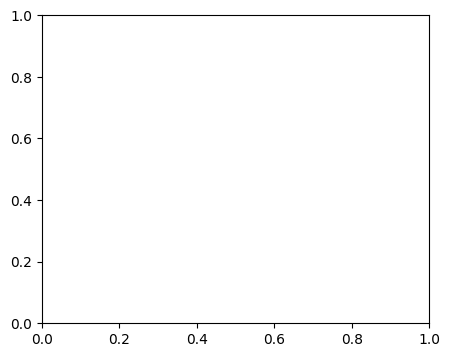

In [12]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["ALLOW", "BLOCK"], yticklabels=["ALLOW", "BLOCK"], ax=ax,
)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("Confusion matrix (overall, threshold=0.5)")
plt.tight_layout()
plt.show()


NameError: name 'sns' is not defined

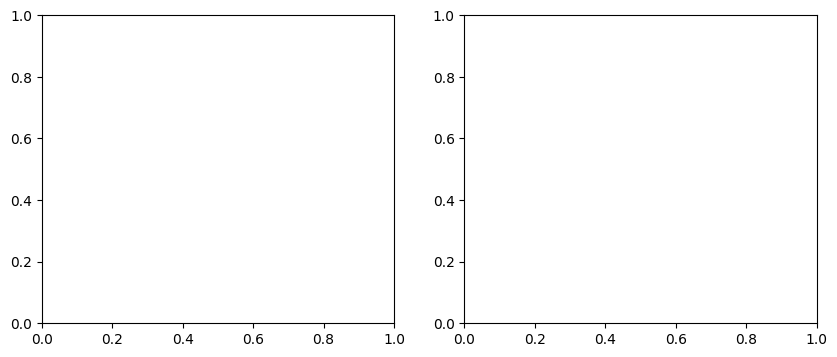

In [13]:
# Per-type recall_block_TPR & FPR barplots
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.barplot(data=df_type_metrics, x="type", y="recall_block_TPR", ax=axes[0])
axes[0].set_title("Per-type recall (BLOCK / TPR)")
axes[0].set_ylim(0, 1.05)
sns.barplot(data=df_type_metrics, x="type", y="FPR", ax=axes[1])
axes[1].set_title("Per-type FPR")
axes[1].set_ylim(0, 1.05)
plt.tight_layout()
plt.show()


NameError: name 'RocCurveDisplay' is not defined

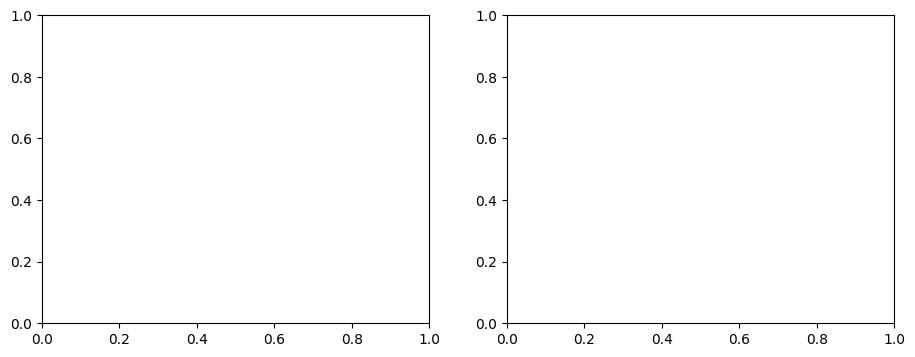

In [14]:
# ROC & Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
RocCurveDisplay.from_predictions(y_test, y_proba_block, ax=axes[0])
axes[0].set_title("ROC curve (overall)")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_block, ax=axes[1])
axes[1].set_title("Precision-Recall curve (overall)")
plt.tight_layout()
plt.show()


### 5.4 ✅ Threshold sweep

`predict_proba` 의 block probability 를 사용해 threshold 별 성능을 비교한다.
후보 threshold: `[0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]`.


In [15]:
THRESHOLDS = [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
sweep_cols = [
    "threshold", "type", "accuracy", "precision", "recall_block_TPR", "f1",
    "FPR", "tn", "fp", "fn", "tp",
]

all_rows = []
for t in THRESHOLDS:
    y_pred_t = (y_proba_block >= t).astype(int)
    m = compute_metrics(y_test.values, y_pred_t, y_proba_block)
    m["threshold"] = t
    m["type"] = "ALL"
    all_rows.append(m)
df_sweep_all = pd.DataFrame(all_rows)[sweep_cols]

print("[threshold sweep — ALL]")
df_sweep_all


NameError: name 'y_proba_block' is not defined

In [16]:
type_rows = []
for t in THRESHOLDS:
    y_pred_t = (y_proba_block >= t).astype(int)
    for tp_name in TYPES:
        mask = (type_test == tp_name).values
        if mask.sum() == 0:
            continue
        m = compute_metrics(
            y_test.values[mask], y_pred_t[mask], y_proba_block[mask]
        )
        m["threshold"] = t
        m["type"] = tp_name
        type_rows.append(m)
df_sweep_type = pd.DataFrame(type_rows)[sweep_cols]
print("[threshold sweep — per type]")
df_sweep_type


NameError: name 'y_proba_block' is not defined

### 5.5 Block Probability Distribution by Type

RandomForest 는 one-class 모델이 아니므로 `predict_proba` 의 block probability (P(y=1)) 분포로 allow / block 분리도를 type 별로 본다. 본 분석의 목적은 **type 별 모델이 필요하다는 의미가 아니라**, pooled RandomForest 모델에서 type 별 threshold 를 다르게 잡을 근거가 있는지 확인하는 것이다.


In [17]:
df_proba = pd.DataFrame({
    "y_true": y_test.values,
    "label_norm": np.where(y_test.values == 0, "ALLOW", "BLOCK"),
    "type": type_test.values,
    "proba_block": y_proba_block,
    "y_pred_0_5": (y_proba_block >= 0.5).astype(int),
})
df_proba.head()


NameError: name 'y_test' is not defined

NameError: name 'sns' is not defined

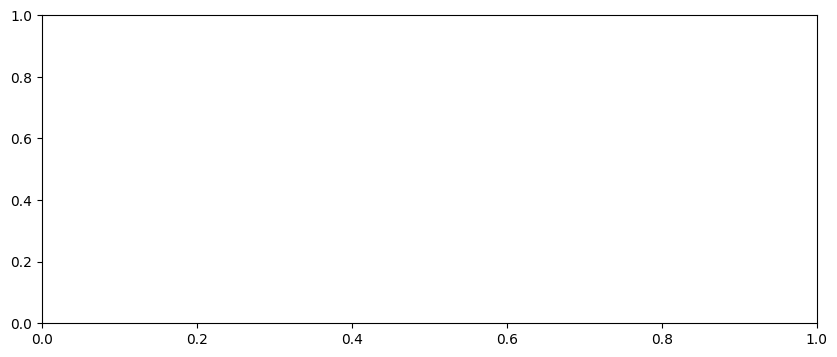

In [18]:
# 시각화 1 — 전체 test set proba_block histogram
fig, ax = plt.subplots(figsize=(10, 4))
sns.histplot(
    data=df_proba, x="proba_block", hue="label_norm",
    bins=30, alpha=0.6, kde=False, ax=ax,
)
ax.axvline(0.5, ls="--", color="red", label="threshold=0.5")
ax.set_title("Block probability distribution (test set, overall)")
ax.legend()
plt.tight_layout()
plt.show()


NameError: name 'df_proba' is not defined

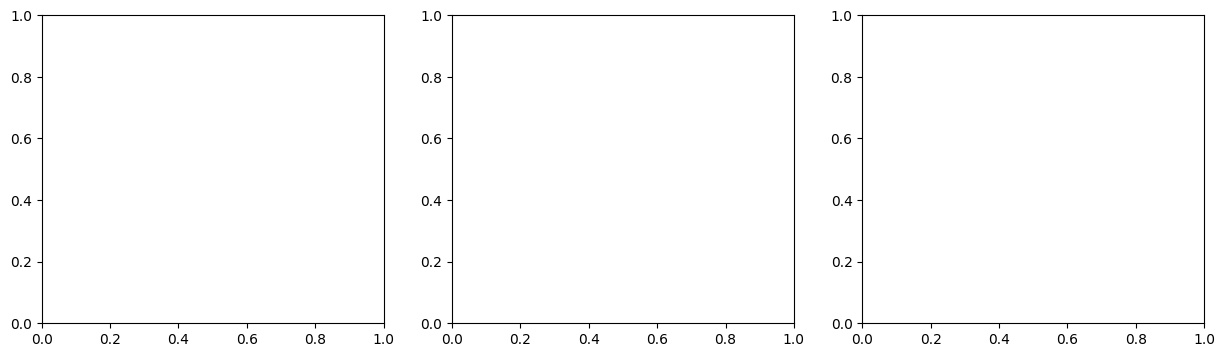

In [19]:
# 시각화 2 — type 별 subplot histogram (raw counts)
fig, axes = plt.subplots(1, len(TYPES), figsize=(5 * len(TYPES), 4), sharey=False)
for ax, t in zip(axes, TYPES):
    sub = df_proba[df_proba["type"] == t]
    sns.histplot(
        data=sub, x="proba_block", hue="label_norm",
        bins=20, alpha=0.6, kde=False, ax=ax,
    )
    ax.axvline(0.5, ls="--", color="red")
    ax.set_title(f"{t} (n_allow={(sub['label_norm']=='ALLOW').sum()}, n_block={(sub['label_norm']=='BLOCK').sum()})")
plt.tight_layout()
plt.show()


NameError: name 'df_proba' is not defined

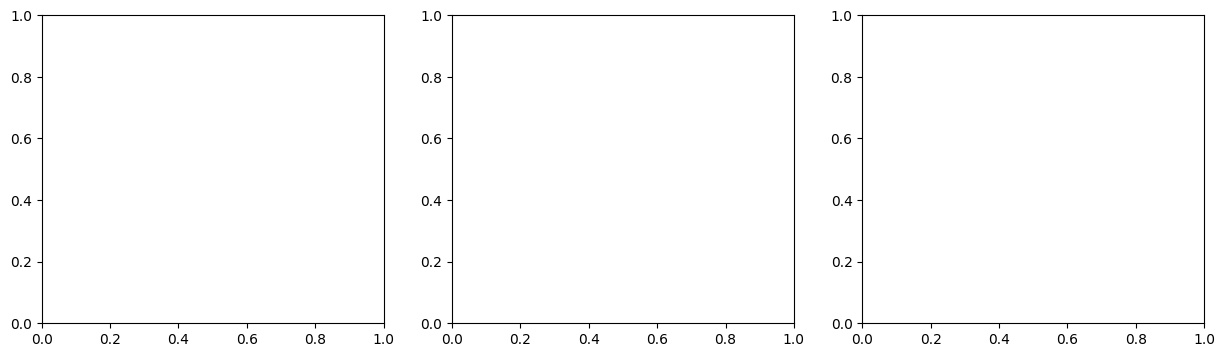

In [20]:
# 시각화 3 — type 별 1:1 balanced histogram (시각화 전용, 평가 X)
fig, axes = plt.subplots(1, len(TYPES), figsize=(5 * len(TYPES), 4), sharey=False)
for ax, t in zip(axes, TYPES):
    sub = df_proba[df_proba["type"] == t]
    a = sub[sub["label_norm"] == "ALLOW"]
    b = sub[sub["label_norm"] == "BLOCK"]
    n_min = min(len(a), len(b))
    if n_min == 0:
        ax.set_title(f"{t} (skip: n_min=0)")
        continue
    a_s = a.sample(n=n_min, random_state=args.RANDOM_STATE)
    b_s = b.sample(n=n_min, random_state=args.RANDOM_STATE)
    sub_bal = pd.concat([a_s, b_s])
    sns.histplot(
        data=sub_bal, x="proba_block", hue="label_norm",
        bins=20, alpha=0.6, kde=False, ax=ax,
    )
    ax.axvline(0.5, ls="--", color="red")
    ax.set_title(f"{t} (balanced n_min={n_min})")
plt.tight_layout()
plt.show()


NameError: name 'sns' is not defined

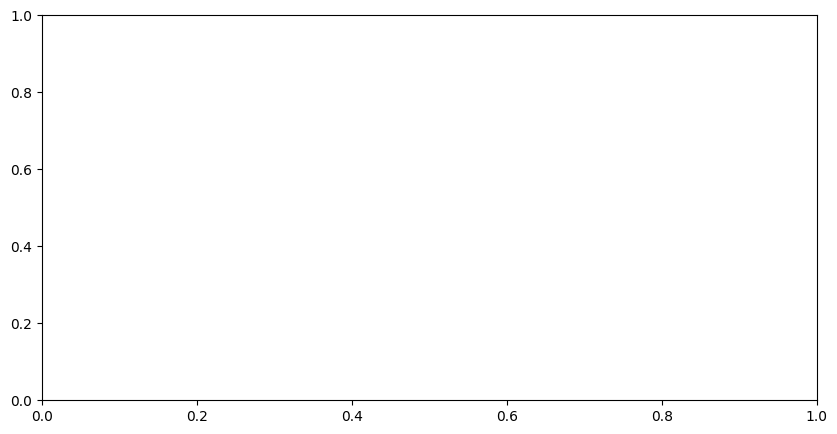

In [21]:
# 시각화 4 — type 별 violin plot
fig, ax = plt.subplots(figsize=(10, 5))
sns.violinplot(
    data=df_proba, x="type", y="proba_block", hue="label_norm",
    split=True, inner="quartile", ax=ax,
)
ax.axhline(0.5, ls="--", color="red")
ax.set_title("Per-type proba_block (violin, split by label)")
plt.tight_layout()
plt.show()
# 대안: boxplot 으로 보고 싶다면 아래 한 줄을 활성화하면 된다.
# sns.boxplot(data=df_proba, x="type", y="proba_block", hue="label_norm")


In [22]:
# 정량 지표 테이블 — type 별 proba_block 분포 통계
stats_rows = []
for t in TYPES:
    sub = df_proba[df_proba["type"] == t]
    a = sub[sub["label_norm"] == "ALLOW"]["proba_block"]
    b = sub[sub["label_norm"] == "BLOCK"]["proba_block"]
    n_allow, n_block = len(a), len(b)
    row = {
        "type": t,
        "n_allow": n_allow,
        "n_block": n_block,
        "allow_proba_mean": a.mean() if n_allow else np.nan,
        "block_proba_mean": b.mean() if n_block else np.nan,
        "allow_proba_median": a.median() if n_allow else np.nan,
        "block_proba_median": b.median() if n_block else np.nan,
        "allow_q75": a.quantile(0.75) if n_allow else np.nan,
        "block_q25": b.quantile(0.25) if n_block else np.nan,
    }
    row["proba_gap_mean"] = row["block_proba_mean"] - row["allow_proba_mean"]
    row["proba_gap_median"] = row["block_proba_median"] - row["allow_proba_median"]
    row["separation_margin"] = row["block_q25"] - row["allow_q75"]
    y_true_sub = sub["y_true"].values
    score_sub = sub["proba_block"].values
    if len(np.unique(y_true_sub)) > 1:
        row["roc_auc_by_type"] = float(roc_auc_score(y_true_sub, score_sub))
        row["average_precision_by_type"] = float(average_precision_score(y_true_sub, score_sub))
    else:
        row["roc_auc_by_type"] = np.nan
        row["average_precision_by_type"] = np.nan
    stats_rows.append(row)

stats_cols_order = [
    "type", "n_allow", "n_block",
    "allow_proba_mean", "block_proba_mean", "proba_gap_mean",
    "allow_proba_median", "block_proba_median", "proba_gap_median",
    "allow_q75", "block_q25", "separation_margin",
    "roc_auc_by_type", "average_precision_by_type",
]
df_proba_stats = pd.DataFrame(stats_rows)[stats_cols_order]
df_proba_stats


NameError: name 'df_proba' is not defined

In [23]:
# 자동 해석 print — gap_mean 대/소 기준값은 임의 default (운영 합의 전 안)
GAP_BIG = 0.2
print(f"(기준: proba_gap_mean >= {GAP_BIG} → '대', separation_margin > 0 → 분리 양호)")
for _, row in df_proba_stats.iterrows():
    t = row["type"]
    gap = row["proba_gap_mean"]
    sep = row["separation_margin"]
    big = (not pd.isna(gap)) and gap >= GAP_BIG
    if big and (not pd.isna(sep)) and sep > 0:
        print(f"[{t}] gap_mean={gap:.3f}, separation_margin={sep:.3f} → threshold 조정 효과적일 가능성 높음")
    elif big:
        print(f"[{t}] gap_mean={gap:.3f}, separation_margin={sep:.3f} → 일부 겹침. threshold 조정 가능하나 FPR/TPR trade-off 존재")
    else:
        print(f"[{t}] gap_mean={gap:.3f}, separation_margin={sep:.3f} → 현재 feature / model 로 해당 type 분리 어려움")


(기준: proba_gap_mean >= 0.2 → '대', separation_margin > 0 → 분리 양호)


NameError: name 'df_proba_stats' is not defined

## 6. 모델 저장

저장 위치: `../model_joblib/randomforest_28_allow_block_type_v1/`

- `randomforest_pipeline.joblib` — imputer + RandomForest 포함 sklearn Pipeline
- `feature_names.joblib` — `selected_features` 리스트
- `metadata.joblib` — run config, label mapping, model params, overall / type metrics


In [24]:
import json
from datetime import datetime


def _json_safe(x):
    if isinstance(x, dict):
        return {str(k): _json_safe(v) for k, v in x.items()}
    if isinstance(x, (list, tuple)):
        return [_json_safe(v) for v in x]
    if isinstance(x, np.ndarray):
        return [_json_safe(v) for v in x.tolist()]
    if isinstance(x, np.integer):
        return int(x)
    if isinstance(x, np.floating):
        f = float(x)
        return None if f != f else f
    if isinstance(x, np.bool_):
        return bool(x)
    if isinstance(x, float):
        return None if x != x else x
    return x


if args.SAVE_MODEL:
    os.makedirs(args.MODEL_SAVE_DIR, exist_ok=True)

    # 1) model.joblib
    model_path = os.path.join(args.MODEL_SAVE_DIR, "model.joblib")
    joblib.dump(pipeline, model_path)

    # 2) meta.json
    meta = {
        "model_name": args.RUN_VERSION,
        "run_version": args.RUN_VERSION,
        "model_type": "RandomForestClassifier",
        "trained_at": datetime.now().isoformat(timespec="seconds"),
        "label_mapping": {"ALLOW": 0, "BLOCK": 1},
        "feature_names": selected_features,
        "n_features": len(selected_features),
        "excluded_features": excluded_features,
        "dataset": {
            "data_root": args.DATA_ROOT,
            "test_size": args.TEST_SIZE,
            "random_state": args.RANDOM_STATE,
            "max_missing_rate": args.MAX_MISSING_RATE,
        },
        "model_params": pipeline.named_steps["model"].get_params(),
    }
    meta_path = os.path.join(args.MODEL_SAVE_DIR, "meta.json")
    with open(meta_path, "w", encoding="utf-8") as f:
        json.dump(_json_safe(meta), f, ensure_ascii=False, indent=2)

    # 3) metrics.json
    metrics_data = {
        "overall": overall_metrics,
        "by_type": type_metrics_dict,
    }
    metrics_path_out = os.path.join(args.MODEL_SAVE_DIR, "metrics.json")
    with open(metrics_path_out, "w", encoding="utf-8") as f:
        json.dump(_json_safe(metrics_data), f, ensure_ascii=False, indent=2)

    print("saved:")
    print(f"  {os.path.abspath(model_path)}")
    print(f"  {os.path.abspath(meta_path)}")
    print(f"  {os.path.abspath(metrics_path_out)}")
else:
    print("SAVE_MODEL=False -- 모델 저장 건너뜀.")

NameError: name 'args' is not defined

## 7. 결과 리포트

자동 요약: 전체 성능 / type 별 block recall / IF 대비 CAPTCHA 개선 여부 / FPR / feature importance / 채택 판단.


In [25]:
print("=== 1. 전체 RandomForest 성능 ===")
for k, v in overall_metrics.items():
    print(f"  {k}: {v}")

print("\n=== 2. type별 block recall 비교 ===")
print(df_type_metrics[["type", "recall_block_TPR", "FPR", "roc_auc", "average_precision"]].to_string(index=False))


=== 1. 전체 RandomForest 성능 ===


NameError: name 'overall_metrics' is not defined

In [26]:
# 3. CAPTCHA recall vs IF baseline
IF_CAPTCHA_RECALL = 0.245
IF_POOLED_RECALL = 0.617
FPR_HIGH = 0.2
TYPE_RECALL_GAP_HIGH = 0.2

captcha_row = df_type_metrics[df_type_metrics["type"] == "CAPTCHA"]
if len(captcha_row) > 0:
    captcha_recall = float(captcha_row["recall_block_TPR"].iloc[0])
else:
    captcha_recall = np.nan

print("\n=== 3. CAPTCHA recall vs Isolation Forest baseline ===")
print(f"  IF CAPTCHA recall (baseline): {IF_CAPTCHA_RECALL}")
print(f"  RF CAPTCHA recall          : {captcha_recall}")
if not np.isnan(captcha_recall) and captcha_recall > IF_CAPTCHA_RECALL:
    print("  → RF CAPTCHA recall 이 IF 보다 높음. supervised 모델이 CAPTCHA 에 유리.")
else:
    print("  → RF CAPTCHA recall 이 IF 대비 개선 미흡.")

print("\n=== 4. FPR 높은 type ===")
high_fpr = df_type_metrics[df_type_metrics["FPR"] > FPR_HIGH]
if len(high_fpr) == 0:
    print(f"  FPR > {FPR_HIGH} 인 type 없음.")
else:
    for _, row in high_fpr.iterrows():
        print(f"  [{row['type']}] FPR={row['FPR']:.3f} > {FPR_HIGH}")


NameError: name 'df_type_metrics' is not defined

In [27]:
# 5. Feature importance top 20
imp = pipeline.named_steps["model"].feature_importances_
feat_imp_df = (
    pd.DataFrame({"feature": selected_features, "importance": imp})
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)
print("\n=== 5. Feature importance (top 20) ===")
print(feat_imp_df.head(20).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=feat_imp_df.head(20), y="feature", x="importance", ax=ax)
ax.set_title("Top 20 feature importance (RandomForest)")
plt.tight_layout()
plt.show()


NameError: name 'pipeline' is not defined

In [28]:
# 6. 채택 판단
overall_recall = overall_metrics["recall_block_TPR"]
overall_fpr = overall_metrics["FPR"]
recall_max_minus_min = float(df_type_metrics["recall_block_TPR"].max() - df_type_metrics["recall_block_TPR"].min())

print("\n=== 6. RandomForest 채택 판단 ===")
print(f"  overall recall (BLOCK / TPR): {overall_recall:.3f}")
print(f"  overall FPR                 : {overall_fpr:.3f}")
print(f"  type별 recall max-min       : {recall_max_minus_min:.3f}")
print(f"  (참고 IF baseline) pooled recall: {IF_POOLED_RECALL}, CAPTCHA recall: {IF_CAPTCHA_RECALL}")

verdicts = []
if not np.isnan(captcha_recall) and captcha_recall > IF_CAPTCHA_RECALL:
    verdicts.append(f"CAPTCHA recall {captcha_recall:.3f} > IF {IF_CAPTCHA_RECALL} → supervised 모델이 CAPTCHA 에 유리")
if overall_recall > IF_POOLED_RECALL and (np.isnan(overall_fpr) or overall_fpr <= FPR_HIGH):
    verdicts.append(
        f"overall recall {overall_recall:.3f} > IF pooled {IF_POOLED_RECALL} & FPR {overall_fpr:.3f} ≤ {FPR_HIGH} "
        "→ RandomForest baseline 유망 (다음 실험 후보로 채택 권장)"
    )
if not np.isnan(overall_fpr) and overall_fpr > FPR_HIGH:
    verdicts.append(f"overall FPR {overall_fpr:.3f} > {FPR_HIGH} → threshold 조정 필요")
if recall_max_minus_min > TYPE_RECALL_GAP_HIGH:
    verdicts.append(
        f"type별 recall 편차 {recall_max_minus_min:.3f} > {TYPE_RECALL_GAP_HIGH} "
        "→ type별 threshold 또는 type별 feature 재검토 필요"
    )

if not verdicts:
    print("  (자동 판단 룰에 걸린 항목 없음 — 수동 검토 권장)")
for v in verdicts:
    print(f"  - {v}")


NameError: name 'overall_metrics' is not defined

## 8. Threshold 설정

추론 시 사용할 threshold 정보를 정리한다. RandomForest 는 supervised 모델이므로 `predict_proba(X)[:, 1]` 의 `P_BLOCK` 을 임계값과 비교한다.

- `global_threshold` — 전체 운영 기본값 (0.5).
- `type_thresholds` — 추론 데이터에 `type` 정보가 있을 때 사용할 optional 임계값.
- `fallback_threshold` — type 정보가 없거나 dict 에 없는 type 일 때 사용 (= global).

본 노트북 §5.4 threshold sweep 과 §5.5 type 별 proba 분포 결과로부터, BOOKING / DETAIL 은 0.5 default, CAPTCHA 는 BLOCK recall 추가 확보 여지가 있어 0.3 candidate 를 함께 보관한다.


### 8.1 기존 metadata.joblib 검사


In [29]:
meta_path = os.path.join(args.MODEL_SAVE_DIR, "meta.json")
with open(meta_path, encoding="utf-8") as f:
    existing_meta = json.load(f)

print("[existing meta.json top-level keys]")
for k in existing_meta.keys():
    print(f"  - {k}")

print("\n[snapshot]")
for k, v in existing_meta.items():
    s = repr(v)
    if isinstance(v, (list, dict)) and len(s) > 200:
        print(f"  {k}: <{type(v).__name__} len={len(v)}>")
    else:
        print(f"  {k}: {s}")

NameError: name 'args' is not defined

### 8.2 threshold_config 정의


In [30]:
threshold_config = {
    "model_name": "randomforest_28_allow_block_type_v1",
    "default_strategy": "global_threshold",
    "global_threshold": 0.5,
    "type_thresholds": {
        "BOOKING": 0.5,
        "CAPTCHA": 0.3,
        "DETAIL": 0.5,
    },
    "fallback_threshold": 0.5,
    "positive_class": "BLOCK",
    "positive_class_index": 1,
    "probability_column": "P_BLOCK",
    "decision_rule": "predict BLOCK if P_BLOCK >= threshold",
    "notes": [
        "RandomForest uses predict_proba(X)[:, 1] as P_BLOCK.",
        "Global threshold 0.5 is the current default.",
        "CAPTCHA threshold 0.3 is an experimental candidate to improve BLOCK recall.",
        "Type-specific thresholds should be revalidated with group split or new validation data before production use.",
    ],
}

# 운영 후보 비교용으로 함께 보관 (현재 active 는 type_thresholds 와 동일한 candidate_1)
threshold_config["type_thresholds_candidates"] = {
    "candidate_1_captcha_lowered": {"BOOKING": 0.5, "CAPTCHA": 0.3, "DETAIL": 0.5},
    "candidate_2_global":           {"BOOKING": 0.5, "CAPTCHA": 0.5, "DETAIL": 0.5},
}
threshold_config


{'model_name': 'randomforest_28_allow_block_type_v1',
 'default_strategy': 'global_threshold',
 'global_threshold': 0.5,
 'type_thresholds': {'BOOKING': 0.5, 'CAPTCHA': 0.3, 'DETAIL': 0.5},
 'fallback_threshold': 0.5,
 'positive_class': 'BLOCK',
 'positive_class_index': 1,
 'probability_column': 'P_BLOCK',
 'decision_rule': 'predict BLOCK if P_BLOCK >= threshold',
 'notes': ['RandomForest uses predict_proba(X)[:, 1] as P_BLOCK.',
  'Global threshold 0.5 is the current default.',
  'CAPTCHA threshold 0.3 is an experimental candidate to improve BLOCK recall.',
  'Type-specific thresholds should be revalidated with group split or new validation data before production use.'],
 'type_thresholds_candidates': {'candidate_1_captcha_lowered': {'BOOKING': 0.5,
   'CAPTCHA': 0.3,
   'DETAIL': 0.5},
  'candidate_2_global': {'BOOKING': 0.5, 'CAPTCHA': 0.5, 'DETAIL': 0.5}}}

### 8.3 Helper functions

추론 시 한 샘플마다 type → threshold → 예측을 만드는 최소 helper. 별도 .py 모듈을 만들지 않고 본 노트북에 보관해 후속 실험 / 서빙 코드에서 그대로 옮겨 쓰기 좋도록 한다.


In [31]:
def get_threshold(sample_type, threshold_config):
    if sample_type in threshold_config["type_thresholds"]:
        return threshold_config["type_thresholds"][sample_type]
    return threshold_config["fallback_threshold"]


def predict_with_threshold(p_block, sample_type, threshold_config):
    threshold = get_threshold(sample_type, threshold_config)
    pred = int(p_block >= threshold)
    return pred, threshold


# 동작 데모: known/unknown type, threshold 경계, None 입력
demo_cases = [
    ("BOOKING", 0.55),
    ("CAPTCHA", 0.35),
    ("CAPTCHA", 0.25),
    ("DETAIL", 0.60),
    ("UNKNOWN_TYPE", 0.55),
    (None, 0.55),
]
for sample_type, p in demo_cases:
    pred, thr = predict_with_threshold(p, sample_type, threshold_config)
    print(f"  type={str(sample_type):>14}  P_BLOCK={p:.2f}  threshold={thr}  pred={pred}")


  type=       BOOKING  P_BLOCK=0.55  threshold=0.5  pred=1
  type=       CAPTCHA  P_BLOCK=0.35  threshold=0.3  pred=1
  type=       CAPTCHA  P_BLOCK=0.25  threshold=0.3  pred=0
  type=        DETAIL  P_BLOCK=0.60  threshold=0.5  pred=1
  type=  UNKNOWN_TYPE  P_BLOCK=0.55  threshold=0.5  pred=1
  type=          None  P_BLOCK=0.55  threshold=0.5  pred=1


### 8.4 저장 — threshold_config.joblib (신규) & metadata.joblib (threshold_config 키 추가)

`randomforest_pipeline.joblib`, `feature_names.joblib` 은 건드리지 않는다. metadata 는 기존 키를 그대로 두고 `threshold_config` 키만 추가/덮어쓰기.


In [32]:
# meta.json 의 threshold_config 키를 업데이트 저장
meta_path = os.path.join(args.MODEL_SAVE_DIR, "meta.json")
with open(meta_path, encoding="utf-8") as f:
    existing_meta = json.load(f)

existing_meta["threshold_config"] = _json_safe(threshold_config)

with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(existing_meta, f, ensure_ascii=False, indent=2)

print(f"updated: {os.path.abspath(meta_path)}  (threshold_config added)")

NameError: name 'args' is not defined

### 8.5 재로드 검증


In [33]:
meta_path = os.path.join(args.MODEL_SAVE_DIR, "meta.json")
with open(meta_path, encoding="utf-8") as f:
    reloaded_meta = json.load(f)

print("[reloaded meta.json top-level keys]")
for k in reloaded_meta.keys():
    print(f"  - {k}")

print("\n[reloaded meta['threshold_config']]")
for k, v in reloaded_meta["threshold_config"].items():
    print(f"  {k}: {v}")

# 일치 sanity (방금 저장한 in-memory threshold_config 와 동일해야 함)
assert reloaded_meta["threshold_config"] == _json_safe(threshold_config), "threshold_config mismatch"
print("\nmeta.json['threshold_config'] == in-memory threshold_config : OK")

NameError: name 'args' is not defined